<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td align="center" width="55%" style="border: none;">
      <h2>Centro de Investigación en Matemáticas, A.C.</h2>
    </td>
  </tr>
</table>


<h3 align="center">Entrenamiento de modelos de aprendizaje CON CLASES BALANCEADAS para la clasificación de superpíxeles utilizando GridSearch</h3>

<h4 align="center">Autor: Sarahi Ventura Angoa</h4>

<p align="center">Maestría en Cómputo Estadístico - CIMAT Mty</p>
<p align="center"> Septiembre 2025</p>


<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <p style="margin:0 0 10px 0;">
    Este <code>notebook</code> entrena y evalúa varios modelos de aprendizaje automático para la 
    <b>clasificación multiclase</b> de superpíxeles en categorías como 
    <i>Arbol</i>, <i>Suelo Desnudo</i>, <i>Pavimento</i>, <i>Cuerpo de Agua</i>, 
    <i>Techo de Lámina</i>, <i>Techo de Losa</i>, <i>Arbusto</i>, 
    <i>Hierba y pasto seco</i>, <i>Hierba y pasto verde</i> y <i>Sombra</i>.
  </p>

  <h4 style="margin-top:10px;margin-bottom:6px;">Estrategia</h4>
  <ul style="margin-top:0;">
    <li>
      <b>Submuestreo balanceado</b>: se limita el tamaño a <b>5 000 superpíxeles por categoría</b> 
      (con <code>random_state=42</code>) para trabajar con un conjunto <b>equilibrado</b>.
    </li>
    <li>
      <b>Entrenamiento y selección</b>: se realiza una <b>búsqueda exhaustiva</b> de hiperparámetros mediante 
      <code>GridSearchCV</code> con <b>validación cruzada estratificada</b>, 
      usando <b>pipelines</b> para evitar fuga de información (el escalado se ajusta sólo con <code>X_train</code>).
    </li>
    <li>
      <b>Comparación</b>: se reportan métricas globales y por clase; además 
      se miden y comparan <b>tiempos de entrenamiento</b> y <b>tiempos de predicción</b>.
    </li>
  </ul>

  <h4 style="margin-top:10px;margin-bottom:6px;">Modelos evaluados</h4>
  <ul style="margin-top:0;">
    <li>Vecinos más cercanos (K-Nearest Neighbors, KNN)</li>
    <li>Regresión Logística (Logistic Regression, RL)</li>
    <li>Máquinas de Soporte Vectorial (Support Vector Machines, SVM)</li>
    <li>Random Forest (Random Forest, RF)</li>
    <li>Red neuronal tipo MLP en <code>PyTorch</code> (Multilayer Perceptron, MLP, with <i>Dropout</i>)</li>
  </ul>

  <h4 style="margin-top:10px;margin-bottom:6px;">Qué se reporta</h4>
  <ul style="margin-top:0;">
    <li><b>Mejor configuración</b> por modelo (según <code>f1_weighted</code> en CV).</li>
    <li><b>Reporte de clasificación</b> por clase y global.</li>
    <li><b>Matriz de confusión</b>.</li>
    <li><b>Tiempos</b> (entrenamiento y predicción) del mejor pipeline por modelo.</li>
  </ul>

  <h4 style="margin-top:10px;margin-bottom:6px;">Gráficas generadas</h4>
  <ul style="margin-top:0;">
    <li><b>Métricas por clase</b> (F1 por clase) comparando modelos.</li>
    <li><b>Tiempos de entrenamiento</b> y <b>tiempos de predicción</b> por modelo.</li>
  </ul>

  <p style="margin-top:10px;color:#555;">
    <b>Nota:</b> tras el submuestreo, el conjunto queda <b>balanceado</b>. Por ello, en el MLP
    <u>no</u> se emplean <i>class weights</i>; se optimiza con <code>CrossEntropyLoss</code> estándar y 
    se reportan <code>F1-weighted</code> y <code>Balanced Accuracy</code> para una comparación consistente.
  </p>
</div>


In [ ]:
import os, time, math                      # utilidades del sistema y cronómetro
import numpy as np                         # arreglos numéricos
import pandas as pd                        # dataframes
import matplotlib.pyplot as plt            # gráficos
import seaborn as sns                      # gráficos estadísticos

# ── Scikit-learn: split, escala, métricas, CV y pesos de clase ────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# (Opcional) GridSearch y modelos clásicos para comparar
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import joblib                                # guardar scaler/modelos sklearn

# ── PyTorch: MLP con Dropout para tabular ─────────────────────────────────────
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader  # tabular→tensores/batches
from sklearn.pipeline import Pipeline
from sklearn.base import clone

print("Todas las bibliotecas están funcionando correctamente!")



Todas las bibliotecas están funcionando correctamente!


<h2>Rutas del conjunto de datos</h2>

<div class="alert alert-block alert-success" style="background:#e6ffed;border-left:6px solid #34d058;padding:10px 12px;border-radius:6px">
<b>Rutas de origen</b>: directorios con los archivos <i>.csv</i> etiquetados. <br>
<b>Nota</b>: cada archivo comienza con el prefijo <code>Etiquetado_</code>.
</div>


In [2]:
# --- Rutas de carpetas que contienen los archivos .csv con datos etiquetados ---
dir_carpeta_1 = '/home/victor/Documents/Etiquetadas_solo_categorias_interes/Etiquetador_2_0/'
dir_carpeta_2 = '/home/victor/Documents/Etiquetadas_solo_categorias_interes/Etiquetador-INSP/'
dir_carpeta_3 = '/home/victor/Documents/Etiquetadas_solo_categorias_interes/etiquetadas_x51/'
dir_carpeta_4 = '/home/victor/Documents/Etiquetadas_solo_categorias_interes/etiquetadas_la_laguna/'
dir_carpeta_5 = '/home/victor/Documents/Etiquetadas_solo_categorias_interes/etiquetadas_Delicias/'

# Prefijo con el que inician los nombres de archivo .csv (p.ej., 'Etiquetado_XXXX.csv')
prefijo = 'Etiquetado_'


<h2>Lectura y unificación de CSV por carpeta</h2>

<div class="alert alert-block alert-success" style="background:#e6ffed;border-left:6px solid #34d058;padding:10px 12px;border-radius:6px">
<b>Función <code>get_data(dir_data, prefijo)</code></b><br>
Lee todos los <code>.csv</code> en una carpeta, agrega la columna <code>img_file</code> derivada del nombre del archivo, 
y devuelve:
<ul style="margin:6px 0 0 16px">
<li><b>data</b>: DataFrame completo concatenado (todas las columnas originales + <code>img_file</code>)</li>
<li><b>X</b>: DataFrame con covariables (features) [fatía por índice de columnas]</li>
<li><b>y</b>: Series con la etiqueta numérica (columna <code>categoria</code>)</li>
<li><b>y_cat</b>: lista de nombres legibles por cada fila (usando <code>ynames</code>)</li>
<li><b>ynames</b>: diccionario <code>{int: nombre_de_clase}</code></li>
<li><b>imagen</b>: Series con el nombre base del archivo (por fila)</li>
</ul>
</div>


In [3]:
def get_data(dir_data, prefijo):
    """
    Lee todos los CSV de 'dir_data', añade una columna 'img_file' 
    obtenida del nombre del archivo (quitando el 'prefijo' y la extensión),
    y construye:
      - data: DataFrame concatenado
      - X: DataFrame de covariables (features)
      - y: etiquetas numéricas (int), columna 'categoria'
      - y_cat: nombres legibles por fila (map desde ynames)
      - ynames: dict {int: nombre_de_clase}
      - imagen: Series con nombre base del archivo por fila
    """
    data = pd.DataFrame()

    # Recorremos todos los archivos de la carpeta
    for file in os.listdir(dir_data):
        # Cargamos solo CSV
        if file.endswith('.csv'):
            try:
                # Lee el CSV
                temp = pd.read_csv(os.path.join(dir_data, file))

                # img_file: nombre base del archivo sin el prefijo ni la extensión
                #   - len(prefijo): corta 'Etiquetado_' del comienzo
                #   - split('.')[0]: quita extensión
                tt = [file[len(prefijo):].split('.')[0]] * temp.shape[0]
                temp['img_file'] = tt

                # Concatenamos fila a fila
                data = pd.concat([data, temp], ignore_index=True)

            except Exception as e:
                # Si un CSV está corrupto o hay error de lectura, informamos y continuamos
                print(f"Error al cargar {file}: {e}")
        else:
            # Mensaje informativo si hay otros archivos no-CSV en la carpeta
            print(f"Archivo ignorado: {file} (no es CSV)")

    # Validación básica: si nada se cargó, avisamos
    if data.empty:
        raise ValueError("No se encontraron archivos CSV válidos.")

    # Nombre de la columna que almacena la categoria:
    cat = 'categoria'

    # Selección de covariables por posiciones:
    #   las features están desde la 3ra columna (índice 2) hasta la penúltima (índice -1)
    covariables = list(data.columns[2:data.shape[1]-1])

    # Guardamos la columna 'img_file' para devolverla aparte
    imagen = data['img_file']

    # Diccionario de mapeo etiqueta->nombre legible
    ynames = {
        0:'Arbol', 1:'Suelo Desnudo', 2:'Pavimento', 3:'Cuerpo de Agua',
        4:'Techo de Lamina', 5:'Techo de Losa', 6:'Arbusto', 7:'Hierba y pasto seco',
        8:'Hierba y pasto verde', 9:'Sombra'
    }

    # Vector de clase numérica como int (asegura tipo correcto)
    y = data[cat].astype('int')

    # Lista paralela de nombres legibles (según ynames)
    y_cat = [ynames[i] for i in y]

    # Subconjunto de columnas de features
    X = data[covariables]

    return data, X, y, y_cat, ynames, imagen


In [4]:
# ==============================
# 1) Cargar y unir los .csv
# ==============================
# Cada get_data(...) devuelve: data, X, y, y_cat, ynames, imagen
data1, X1, y1, y_cat1, label_encoder1, imagen1 = get_data(dir_carpeta_1, prefijo)
data2, X2, y2, y_cat2, label_encoder2, imagen2 = get_data(dir_carpeta_2, prefijo)
data3, X3, y3, y_cat3, label_encoder3, imagen3 = get_data(dir_carpeta_3, prefijo)
data4, X4, y4, y_cat4, label_encoder4, imagen4 = get_data(dir_carpeta_4, prefijo)
data5, X5, y5, y_cat5, label_encoder5, imagen5 = get_data(dir_carpeta_5, prefijo)

# Unimos todos los DataFrames de anotaciones en uno solo
data = pd.concat([data1, data2, data3, data4, data5], ignore_index=True)


Archivo ignorado: Etiquetado_image_x5_48.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_1005.tif (no es CSV)
Archivo ignorado: requerimentos_etiquetador.txt (no es CSV)
Archivo ignorado: Etiquetado_image_x5_738.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_569.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_17.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_26.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_490.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_1247.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_70.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_35.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_60.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_51.tif (no es CSV)
Archivo ignorado: pixeles_proporciones_por_categoria_etiquetadas_de_img_etiquetar_1.txt (no es CSV)
Archivo ignorado: Etiquetado_image_x5_76.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_65.tif (no es CSV)
Archivo ignorado: Etiquetado_image_

/tmp/ipykernel_7423/1126217603.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, temp], ignore_index=True)


Archivo ignorado: Etiquetado_image_x5_151.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_31.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_59.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_197.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_30.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_62.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_85.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_1969.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_1713.tif (no es CSV)
Archivo ignorado: Etiquetador_2_0_mejorado.py (no es CSV)
Archivo ignorado: Etiquetado_image_x5_29.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_42.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_46.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_45.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_32.tif (no es CSV)
Archivo ignorado: Etiquetado_image_x5_36.tif (no es CSV)
Archivo ignorado: pixeles_proporciones_por_categoria_etiquetadas_de_img_etiquetar


<div class="alert alert-block alert-success">
<b> Submuestreo de categorías, 5000 superpixeles por categoría</b><br>
</div>


In [41]:
# ==============================
# 2) Filtrado y submuestreo
# ==============================
# Filtra filas con categorías válidas (0..9). Se excluye 10 = "Sin etiqueta".
data_filtrada = data[data['categoria'] < 10].copy()

# Máximo número de muestras por categoría
limite = 5000

# Submuestreo balanceado (máx. 'limite' por clase).
# - groupby('categoria'): agrupa por clase.
# - apply(sample(...)): toma aleatoriamente hasta 'limite' filas de cada grupo.
# - random_state: hace el muestreo reproducible.
data_balanceada = (
    data_filtrada
    .groupby('categoria', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), limite), random_state=42))
    .reset_index(drop=True)
)

# Conteo final por clase tras el submuestreo
conteo_balanceado = data_balanceada['categoria'].value_counts().sort_index()
print("Conteo por clase tras el balanceo:\n", conteo_balanceado)

# Diccionario de categorías
ynames = {
    0:'Arbol', 1:'Suelo Desnudo', 2:'Pavimento', 3:'Cuerpo de Agua',
    4:'Techo de Lamina', 5:'Techo de Losa', 6:'Arbusto', 7:'Hierba y pasto seco',
    8:'Hierba y pasto verde', 9:'Sombra'
}

# Mostrar conteo por nombre de clase (si alguna clase no aparece, evitará KeyError)
for i in sorted(ynames.keys()):
    print(f"{ynames[i]:<25}: {int(conteo_balanceado.get(i, 0))} muestras")


Conteo por clase tras el balanceo:
 categoria
0.0    5000
1.0    5000
2.0    5000
3.0    5000
4.0    5000
5.0    5000
6.0    5000
7.0    5000
8.0    5000
9.0    5000
Name: count, dtype: int64
Arbol                    : 5000 muestras
Suelo Desnudo            : 5000 muestras
Pavimento                : 5000 muestras
Cuerpo de Agua           : 5000 muestras
Techo de Lamina          : 5000 muestras
Techo de Losa            : 5000 muestras
Arbusto                  : 5000 muestras
Hierba y pasto seco      : 5000 muestras
Hierba y pasto verde     : 5000 muestras
Sombra                   : 5000 muestras


/tmp/ipykernel_1390134/1121895019.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_filtrada


<div class="alert alert-block alert-success">
<b> Construcción de matrices finales (X, y, imagen)</b><br>
Se seleccionan las <i>covariables</i> (columnas de características) desde <code>data_balanceada</code>, 
se generan el vector de etiquetas <code>y</code> y la lista de nombres de imagen asociados.
</div>

In [42]:
# ==============================
# 3) Extraer covariables, y e imagen
# ==============================
# Las columnas [2 : -1] son las de características:
#   - col 0: categoria
#   - col 1: indice
#   - col 2..penúltima: covariables numéricas
#   - última: 'img_file'
covariables = list(data_balanceada.columns[2:-1])

# DataFrame de características (X)
X = data_balanceada[covariables].copy()

# Vector de etiquetas, como enteros
y = data_balanceada['categoria'].astype(int).copy()

# Lista de nombres de imagen por fila 
imagen = data_balanceada['img_file'].copy()

# (Opcional) nombres legibles de cada muestra, si te sirven:
y_cat = [ynames[i] for i in y]

# Dimensiones resultantes
print("Dimensiones con submuestreo balanceado:")
print(f"DataFrame balanceado: {data_balanceada.shape}")
print(f"Covariables (X): {X.shape}")
print(f"Etiquetas (y): {y.shape}")
print(f"Imágenes: {len(imagen)}")


Dimensiones con submuestreo balanceado:
DataFrame balanceado: (50000, 132)
Covariables (X): (50000, 129)
Etiquetas (y): (50000,)
Imágenes: 50000


<h2>Partición del conjunto de datos: Train/Test</h2>

<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
Datos en entrenamiento (70%) y prueba (30%) manteniendo la proporción de clases.<br>
<b>Estrategia:</b> <code>train_test_split</code> con <b>estratificación</b> (<code>stratify=y</code>) para respetar el desbalance original.<br>
<b>Reproducibilidad:</b> <code>random_state=0</code> fija la semilla; así los splits son siempre los mismos.<br>
El <i>escalado</i> (para KNN, RegLog, SVM, MLP) se ajustará <b>solo con X_train</b> para evitar fuga de información (data leakage).
</div>

In [43]:
# Split estratificado: conserva la proporción de clases en train y test.
# test_size=0.30 -> 30% prueba, 70% entrenamiento
# random_state=0 -> reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=0
)


#
<div class="alert alert-block alert-success">
<b>Vecinos más cercanos (K-Nearest Neighbors, KNN)</b></div>

In [ ]:
# -------------------------------------------------------------------
# 1) Pipeline: StandardScaler -> KNN
# -------------------------------------------------------------------
pipeline_knn= Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


# -------------------------------------------------------------------
# 2) Cuadrícula de hiperparámetros
# -------------------------------------------------------------------
param_grid_knn = [
    {
        'knn__n_neighbors': [5, 11, 15, 21, 27, 35],
        'knn__weights': ['uniform', 'distance'],
        'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'knn__leaf_size': [30, 40],
        'knn__metric': ['minkowski'],
        'knn__p': [1, 2],
        'knn__n_jobs': [1]   # evitar paralelismo doble
    },
    {
        'knn__n_neighbors': [5, 11, 15, 21, 27, 35],
        'knn__weights': ['uniform', 'distance'],
        'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'knn__leaf_size': [30, 40],
        'knn__metric': ['euclidean', 'manhattan'],
        'knn__n_jobs': [1]
    }
]


In [ ]:

# -------------------------------------------------------------------
# 3) GridSearchCV 
# -------------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train) 

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid=[{'knn__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                             'brute'],
                          'knn__leaf_size': [30, 40],
                          'knn__metric': ['minkowski'], 'knn__n_jobs': [1],
                          'knn__n_neighbors': [5, 11, 15, 21, 27, 35],
                          'knn__p': [1, 2],
                          'knn__weights': ['uniform', 'distance']},
                         {'knn__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                             'brute'],
                          'knn__leaf_size': [30, 40],
                          'knn__metric': ['euclidean', 'manhattan'],
                          'knn__n_jobs': [1],
                          'knn__n_neighbors': [5, 11, 15, 21, 27, 35],
                          'knn__weights': ['uniform', 'distance']}],
             scoring='f1_weighted', verbose=1)


Mejores hiperparámetros (seleccionados por f1_weighted):
{'knn__algorithm': 'auto', 'knn__leaf_size': 30, 'knn__metric': 'minkowski', 'knn__n_jobs': 1, 'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance'}
Mejor f1_weighted(CV): 0.6544
Tiempo de entrenamiento (mejor modelo): 0.0898 s

Tiempo de predicción (mejor modelo): 1.1507 s
Accuracy test: 0.6856
F1_weighted test: 0.6872
Balanced accuracy test: 0.6856

Desempeño del modelo por clase:
                      precision    recall  f1-score   support

               Arbol     0.5440    0.5607    0.5522      1500
       Suelo Desnudo     0.5754    0.5700    0.5727      1500
           Pavimento     0.6596    0.7260    0.6912      1500
      Cuerpo de Agua     0.9636    0.9533    0.9584      1500
     Techo de Lamina     0.9293    0.7453    0.8272      1500
       Techo de Losa     0.6416    0.5693    0.6033      1500
             Arbusto     0.5413    0.6600    0.5948      1500
 Hierba y pasto seco     0.6920    0.7820    0.7

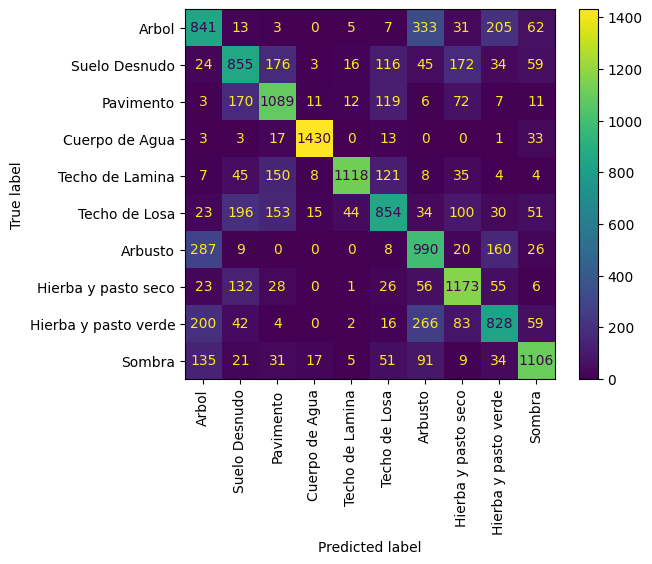

['mejor_pipeline_knn_balanceado.joblib']

In [ ]:
# -------------------------------------------------------------------
# Mejores hiperparamentros encontrados
# -------------------------------------------------------------------

print("\nMejores hiperparámetros (seleccionados por f1_weighted):")
print(grid_search.best_params_)
print(f"Mejor f1_weighted(CV): {grid_search.best_score_:.4f}")


# 4) Mejor pipeline ya ajustado por GridSearch (tras refit)
mejor_pipeline_knn = grid_search.best_estimator_

# Tiempo de entrenamiento SOLO del mejor modelo
if hasattr(grid_search, "refit_time_"):
    tiempo_entrenamiento_knn = grid_search.refit_time_
else:
    # Volver a entrenar desde cero para medir el tiempo de entrenamiento
    mejor_pipeline_knn = clone(grid_search.best_estimator_)
    time_start_train_knn = time.time()
    mejor_pipeline_knn.fit(X_train, y_train)
    time_end_train_knn = time.time()
    tiempo_entrenamiento_knn = time_end_train_knn - time_start_train_knn

print(f"Tiempo de entrenamiento (mejor modelo): {tiempo_entrenamiento_knn:.4f} s")


# -------------------------------------------------------------------
# 5) Mejor modelo y evaluación en test
# -------------------------------------------------------------------
time_star_test_knn= time.time()
y_pred_knn= mejor_pipeline_knn.predict(X_test)
time_end_test_knn = time.time()
tiempo_prediccion_knn = time_end_test_knn -time_star_test_knn


print(f"\nTiempo de predicción (mejor modelo): {tiempo_prediccion_knn:.4f} s")
print(f"Accuracy test: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1_weighted test: {f1_score(y_test, y_pred_knn, average='weighted', zero_division=0):.4f}")

print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_pred_knn):.4f}\n")


# =========================================================
# 6) Reporte por clases
#    Usamos tus nombres de etiquetas (ynames: dict {int: str})
# =========================================================

labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]

print("Desempeño del modelo por clase:")
print(classification_report(
    y_test, y_pred_knn,
    labels=labels_order,
    target_names=target_names,
    digits=4,
    zero_division=0
))


# =========================================================
# 7) Matriz de confusión 
# =========================================================
plt.style.use('default')

cm = confusion_matrix(y_test, y_pred_knn)

# visualizacion de la matriz de confusion 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(ynames.values()))
disp.plot()

plt.xticks(rotation=90)
plt.show()


# -------------------------------------------------------------------
# 8) Guardar el mejor modelo
# -------------------------------------------------------------------

joblib.dump(mejor_pipeline_knn, 'mejor_pipeline_knn_balanceado.joblib')


<div class="alert alert-block alert-info">
<b> Regresión Logística (Logistic Regression, RL)</b>
</div>

In [47]:
# -------------------------------------------------------------------
# 1) Pipeline: StandardScaler -> Regresión Logística
# -------------------------------------------------------------------
pipeline_reg_log = Pipeline([
    ('scaler_reg_log', StandardScaler()),
    ('reg_log', LogisticRegression(
        class_weight=None,
        random_state=42,
        tol=1e-4,
        multi_class='multinomial'  
    ))
])


# -------------------------------------------------------------------
# 2) Cuadrícula de hiperparámetros
# -------------------------------------------------------------------
param_grid_reg_log = {
    'reg_log__C': [0.01, 0.1, 1, 10],
    'reg_log__penalty': ['l2'],
    'reg_log__solver': ['lbfgs', 'saga', 'newton-cg'],
    'reg_log__max_iter': [500, 1000, 5000],
}




In [48]:
# -------------------------------------------------------------------
# 3) GridSearchCV
# -------------------------------------------------------------------
grid_search_reg_log = GridSearchCV(
    estimator=pipeline_reg_log,
    param_grid=param_grid_reg_log,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_reg_log.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


/home/victor/Documents/prueba_modelos/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/victor/Documents/prueba_modelos/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/victor/Documents/prueba_modelos/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/victor/Documents/prueba_modelos/venv/lib/pytho

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler_reg_log', StandardScaler()),
                                       ('reg_log',
                                        LogisticRegression(multi_class='multinomial',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'reg_log__C': [0.01, 0.1, 1, 10],
                         'reg_log__max_iter': [500, 1000, 5000],
                         'reg_log__penalty': ['l2'],
                         'reg_log__solver': ['lbfgs', 'saga', 'newton-cg']},
             scoring='f1_weighted', verbose=1)


Mejores hiperparámetros (seleccionados por f1_weighted):
{'reg_log__C': 10, 'reg_log__max_iter': 500, 'reg_log__penalty': 'l2', 'reg_log__solver': 'lbfgs'}
Mejor f1_weighted (CV): 0.6637
Tiempo de entrenamiento (mejor modelo): 9.0240 s

Tiempo de predicción (mejor modelo): 0.0122 s
Accuracy test: 0.6689
F1_weighted test: 0.6651
Balanced accuracy test: 0.6689

Reporte de clasificación (por clase):
              precision    recall  f1-score   support

           0     0.5098    0.5567    0.5322      1500
           1     0.5629    0.4713    0.5131      1500
           2     0.6614    0.6667    0.6640      1500
           3     0.9668    0.9507    0.9587      1500
           4     0.8387    0.8560    0.8472      1500
           5     0.5791    0.5860    0.5825      1500
           6     0.4909    0.3940    0.4371      1500
           7     0.7430    0.8307    0.7844      1500
           8     0.5771    0.5887    0.5828      1500
           9     0.7131    0.7887    0.7490      1500

   

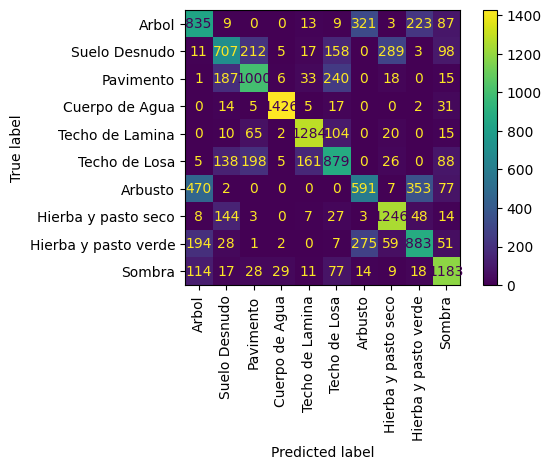

['mejor_pipeline_reg_log_balanceado.joblib']

In [ ]:
# -------------------------------------------------------------------
# Mejores hiperparámetros encontrados
# -------------------------------------------------------------------
print("\nMejores hiperparámetros (seleccionados por f1_weighted):")
print(grid_search_reg_log.best_params_)
print(f"Mejor f1_weighted (CV): {grid_search_reg_log.best_score_:.4f}")

# -------------------------------------------------------------------
# 4) Mejor pipeline (refit) 
# -------------------------------------------------------------------
mejor_pipeline_reg_log = grid_search_reg_log.best_estimator_

if hasattr(grid_search_reg_log, "refit_time_"):   
    tiempo_entrenamiento_reg_log = grid_search_reg_log.refit_time_
else:
    mejor_pipeline_reg_log = clone(grid_search_reg_log.best_estimator_)
    time_start_train_reg_log = time.time()
    mejor_pipeline_reg_log.fit(X_train, y_train)
    time_end_train_reg_log = time.time()
    tiempo_entrenamiento_reg_log = time_end_train_reg_log - time_start_train_reg_log

print(f"Tiempo de entrenamiento (mejor modelo): {tiempo_entrenamiento_reg_log:.4f} s")

# -------------------------------------------------------------------
# 5) Mejor modelo y evaluación en test
# -------------------------------------------------------------------
time_star_test_reg_log = time.time()
y_pred_reg_log = mejor_pipeline_reg_log.predict(X_test)
time_end_test_reg_log = time.time()
tiempo_prediccion_reg_log = time_end_test_reg_log - time_star_test_reg_log

print(f"\nTiempo de predicción (mejor modelo): {tiempo_prediccion_reg_log:.4f} s")
print(f"Accuracy test: {accuracy_score(y_test, y_pred_reg_log):.4f}")
print(f"F1_weighted test: {f1_score(y_test, y_pred_reg_log, average='weighted', zero_division=0):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_pred_reg_log):.4f}\n")


# -------------------------------------------------------------------
# 6) Reporte por clases y matriz de confusion
# -------------------------------------------------------------------

print("Reporte de clasificación (por clase):")
print(classification_report(y_test, y_pred_reg_log, digits=4, zero_division=0))


labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]

print("Desempeño del modelo por clase:")
print(classification_report(
    y_test, y_pred_reg_log,
    labels=labels_order,
    target_names=target_names,
    digits=4,
    zero_division=0
))


# =========================================================
# 7) Matriz de confusión
# =========================================================
plt.style.use('default')

cm = confusion_matrix(y_test, y_pred_reg_log, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[ynames[i] for i in labels_order])
disp.plot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 8) Guardar el mejor modelo
# -------------------------------------------------------------------
joblib.dump(mejor_pipeline_reg_log, 'mejor_pipeline_reg_log_balanceado.joblib')



<div class="alert alert-block alert-info">
<b> Máquinas de Soporte Vectorial (Support Vector Machines, SVM)</b>
</div>

In [50]:
# Pipeline SVM
pipeline_svm = Pipeline([
    ('scaler_svm', StandardScaler()),
    ('svm', SVC(class_weight=None))  
])

# Grid de hiperparámetros

param_grid_svm = [
    # Kernel RBF
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': [0.001, 0.01, 0.1, 'scale'],
    },
    # Kernel POLY
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': [0.001, 0.01, 0.1, 'scale'],
        'svm__degree': [2, 3, 4]       
    }
]


In [51]:
# GridSearchCV
grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_svm.fit(X_train, y_train)


Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler_svm', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid=[{'svm__C': [0.1, 1, 10],
                          'svm__gamma': [0.001, 0.01, 0.1, 'scale'],
                          'svm__kernel': ['rbf']},
                         {'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3, 4],
                          'svm__gamma': [0.001, 0.01, 0.1, 'scale'],
                          'svm__kernel': ['poly']}],
             scoring='f1_weighted', verbose=1)


Mejores hiperparámetros SVM (seleccionados por f1_weighted):
{'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 0.1, 'svm__kernel': 'poly'}
Mejor f1_weighted (CV): 0.7379
Tiempo de entrenamiento (mejor SVM): 248.8249 s

Tiempo de predicción (mejor SVM): 21.1585 s
Accuracy test: 0.7563
F1_weighted test: 0.7567
Balanced accuracy test: 0.7563

Desempeño del modelo por clase:
                      precision    recall  f1-score   support

               Arbol     0.5700    0.6353    0.6009      1500
       Suelo Desnudo     0.6742    0.7573    0.7133      1500
           Pavimento     0.7674    0.7700    0.7687      1500
      Cuerpo de Agua     0.9591    0.9700    0.9645      1500
     Techo de Lamina     0.9069    0.8573    0.8814      1500
       Techo de Losa     0.7368    0.7353    0.7361      1500
             Arbusto     0.5941    0.5260    0.5580      1500
 Hierba y pasto seco     0.8697    0.8453    0.8573      1500
Hierba y pasto verde     0.6797    0.6620    0.6707      1500
        

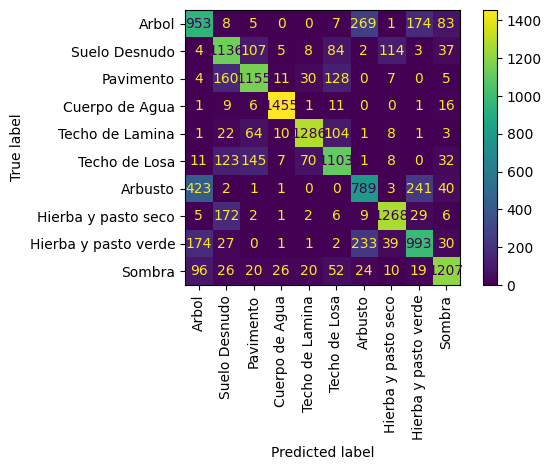

['mejor_pipeline_svm_balanceado.joblib']

In [52]:

# -------------------------------------------------------------------
# Mejores hiperparámetros encontrados
# -------------------------------------------------------------------
print("\nMejores hiperparámetros SVM (seleccionados por f1_weighted):")
print(grid_search_svm.best_params_)
print(f"Mejor f1_weighted (CV): {grid_search_svm.best_score_:.4f}")

# -------------------------------------------------------------------
# 4) Mejor pipeline (refit) y tiempo de ENTRENAMIENTO SOLO del mejor
# -------------------------------------------------------------------
mejor_pipeline_svm = grid_search_svm.best_estimator_

if hasattr(grid_search_svm, "refit_time_"):
    tiempo_entrenamiento_svm = grid_search_svm.refit_time_
else:
    mejor_pipeline_svm = clone(grid_search_svm.best_estimator_)
    time_start_train_svm = time.time()
    mejor_pipeline_svm.fit(X_train, y_train)
    time_end_train_svm = time.time() 
    tiempo_entrenamiento_svm = time_end_train_svm - time_start_train_svm

print(f"Tiempo de entrenamiento (mejor SVM): {tiempo_entrenamiento_svm:.4f} s")

# -------------------------------------------------------------------
# 5) Predicción y métricas en TEST
# -------------------------------------------------------------------
time_start_test_svm = time.time()
y_pred_svm = mejor_pipeline_svm.predict(X_test)
time_end_test_svm = time.time()
tiempo_prediccion_svm = time_end_test_svm - time_start_test_svm


print(f"\nTiempo de predicción (mejor SVM): {tiempo_prediccion_svm:.4f} s")
print(f"Accuracy test: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1_weighted test: {f1_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_pred_svm):.4f}\n")


# =========================================================
# 6) Reporte por clases
#    Usamos tus nombres de etiquetas (ynames: dict {int: str})
# =========================================================

labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]

print("Desempeño del modelo por clase:")
print(classification_report(
    y_test, y_pred_svm,
    labels=labels_order,
    target_names=target_names,
    digits=4,
    zero_division=0
))


# =========================================================
# 7) Matriz de confusión 
# =========================================================
plt.style.use('default')
cm = confusion_matrix(y_test, y_pred_svm, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[ynames[i] for i in labels_order])
disp.plot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 8) Guardar el mejor modelo
# -------------------------------------------------------------------
joblib.dump(mejor_pipeline_svm, 'mejor_pipeline_svm_balanceado.joblib')


<div class="alert alert-block alert-info">
<b> Bosque aleatorios (Random Forest, RF)</b>
</div>

In [53]:
# -------------------------------------------------------------------
# 1) Pipeline: (Scaler) -> RandomForest
#    Los árboles no necesitan escalado. Dejamos StandardScaler en el pipeline,
#    pero en el grid probamos 'passthrough' para evitar costo innecesario.
# -------------------------------------------------------------------
pipeline_rf = Pipeline([
    ('scaler_rf', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])


# -------------------------------------------------------------------
# 2) Grid de hiperparámetros (dos dicts para evitar combinaciones inválidas)
# -------------------------------------------------------------------

param_grid_rf = [
    # Con bootstrap (permite max_samples)
    {
        'scaler_rf': ['passthrough'],        # árboles no requieren escalado
        'rf__n_estimators': [200, 400, 500,701],
        'rf__max_depth': [None, 15, 25],
        'rf__min_samples_split': [2, 5],
        'rf__min_samples_leaf': [1, 2],
        'rf__max_features': ['sqrt', 0.5],
        'rf__bootstrap': [True],
        'rf__max_samples': [None, 0.7],
        'rf__criterion': ['gini', 'entropy'],
        'rf__n_jobs': [-1],
    },
    # Sin bootstrap (no usar max_samples aquí)
    {
        'scaler_rf': ['passthrough'],
        'rf__n_estimators': [200, 400, 500, 701],
        'rf__max_depth': [None, 15, 25],
        'rf__min_samples_split': [2, 5],
        'rf__min_samples_leaf': [1, 2],
        'rf__max_features': ['sqrt', 0.5],
        'rf__bootstrap': [False],
        'rf__criterion': ['gini', 'entropy'],
        'rf__n_jobs': [-1],
    }
]

grid_search_rf_version_2 = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
    n_jobs=-1,
    verbose=1
)
grid_search_rf_version_2.fit(X_train, y_train)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


/home/victor/Documents/prueba_modelos/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler_rf', StandardScaler()),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'rf__bootstrap': [True],
                          'rf__criterion': ['gini', 'entropy'],
                          'rf__max_depth': [None, 15, 25],
                          'rf__max_features': ['sqrt', 0.5],
                          'rf__max_samples': [None, 0.7],
                          '...
                          'rf__n_estimators': [200, 400, 500, 701],
                          'rf__n_jobs': [-1], 'scaler_rf': ['passthrough']},
                         {'rf__bootstrap': [False],
                          'rf__criterion': ['gini', 'entropy'],
                          'rf__max_depth': [None, 15, 25],
                          'rf__max_features': ['sqrt', 0.5],
                          'rf__min_samples_leaf': [1, 2],
                          'rf__min_samples_split': [2, 5],
                          'rf__n_estimators': [200, 400, 500, 701],
                          'rf__n_jobs': [-1], 'scaler_rf': ['passthrough']}],
             scoring='f1_weighted', verbose=1)


Mejores hiperparámetros RF (seleccionados por f1_weighted):
{'rf__bootstrap': False, 'rf__criterion': 'entropy', 'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 701, 'rf__n_jobs': -1, 'scaler_rf': 'passthrough'}
Mejor f1_weighted (CV): 0.7948
Tiempo de entrenamiento (mejor RF): 577.6851 s

Tiempo de predicción (mejor RF): 0.3730 s
Accuracy test: 0.8181
F1_weighted test: 0.8177
Balanced accuracy test: 0.8181

Desempeño del modelo por clase (RF):
                      precision    recall  f1-score   support

               Arbol     0.6750    0.7200    0.6968      1500
       Suelo Desnudo     0.7972    0.7520    0.7739      1500
           Pavimento     0.8019    0.8313    0.8164      1500
      Cuerpo de Agua     0.9885    0.9727    0.9805      1500
     Techo de Lamina     0.9263    0.9133    0.9198      1500
       Techo de Losa     0.7928    0.8187    0.8055      1500
             Arbusto     0.7375    0.680

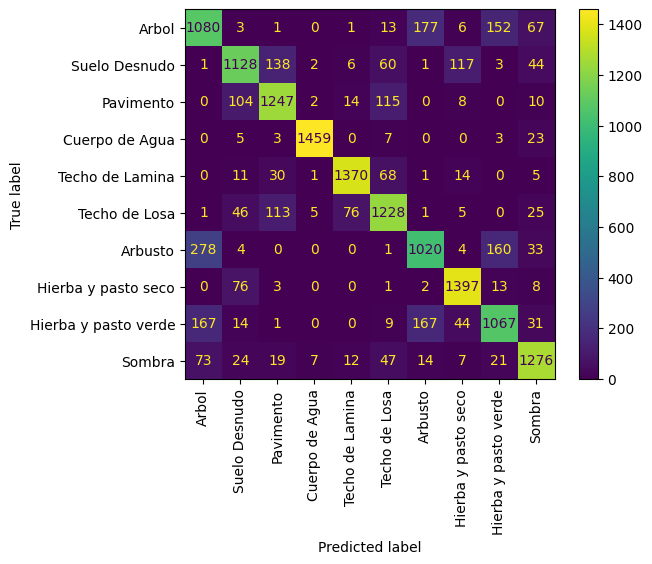

['mejor_pipeline_rf_sin_escalar_balanceado.joblib']

In [54]:

# -------------------------------------------------------------------
# Mejores hiperparámetros encontrados
# -------------------------------------------------------------------
print("\nMejores hiperparámetros RF (seleccionados por f1_weighted):")
print(grid_search_rf_version_2.best_params_)
print(f"Mejor f1_weighted (CV): {grid_search_rf_version_2.best_score_:.4f}")

# -------------------------------------------------------------------
# 4) Mejor pipeline (refit) y tiempo de ENTRENAMIENTO SOLO del mejor
# -------------------------------------------------------------------
mejor_pipeline_rf_version_2 = grid_search_rf_version_2.best_estimator_

if hasattr(grid_search_rf_version_2, "refit_time_"):
    tiempo_entrenamiento_rf_version_2 = grid_search_rf_version_2.refit_time_
else:
    mejor_pipeline_rf_version_2= clone(grid_search_rf_version_2.best_estimator_)
    time_start_train_rf_version_2= time.time()
    mejor_pipeline_rf_version_2.fit(X_train, y_train)
    time_end_train_rf_version_2 = time.time() 
    tiempo_entrenamiento_rf_version_2 = time_end_train_rf_version_2 - time_start_train_rf_version_2
print(f"Tiempo de entrenamiento (mejor RF): {tiempo_entrenamiento_rf_version_2:.4f} s")

# -------------------------------------------------------------------
# 5) Predicción y métricas en TEST
# -------------------------------------------------------------------
time_start_test_rf_version_2 = time.time()
y_pred_rf_version_2= mejor_pipeline_rf_version_2.predict(X_test)
time_end_test_rf_version_2 = time.time()

tiempo_prediccion_rf_version_2 =  time_end_test_rf_version_2 -time_start_test_rf_version_2


print(f"\nTiempo de predicción (mejor RF): {tiempo_prediccion_rf_version_2:.4f} s")
print(f"Accuracy test: {accuracy_score(y_test, y_pred_rf_version_2):.4f}")
print(f"F1_weighted test: {f1_score(y_test, y_pred_rf_version_2, average='weighted', zero_division=0):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_pred_rf_version_2):.4f}\n")


# -------------------------------------------------------------------
# 6) Reporte por clases y MATRIZ DE CONFUSIÓN (etiquetas fijas)
# -------------------------------------------------------------------
labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]

print("Desempeño del modelo por clase (RF):")
print(classification_report(
    y_test, y_pred_rf_version_2,
    labels=labels_order,
    target_names=target_names,
    digits=4,
    zero_division=0
))



# =========================================================
# 7) Matriz de confusión
# =========================================================
plt.style.use('default')

cm = confusion_matrix(y_test, y_pred_rf_version_2)

# visualizacion de la matriz de confusion 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(ynames.values()))
disp.plot()

plt.xticks(rotation=90)
plt.show()


# -------------------------------------------------------------------
# 8) Guardar el mejor modelo
# -------------------------------------------------------------------
import joblib
joblib.dump(mejor_pipeline_rf_version_2, 'mejor_pipeline_rf_sin_escalar_balanceado.joblib')

<div class="alert alert-block alert-info">
<b> Red neuronal tipo MLP en <code>PyTorch</code> (Multilayer Perceptron, MLP, with <i>Dropout</i>)</b>
</div>

In [55]:
# =========================================================
# Definiciones base para MLP en PyTorch (CPU)
# =========================================================
import math, time, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

DEVICE = torch.device("cpu")  # en tu máquina actual es lo correcto

# --- Red densa simple con Dropout (para datos tabulares) ---
class MLP(nn.Module):
    def __init__(self, in_features, n_classes, hidden=(256,128), p=0.5):
        super().__init__()
        capas, prev = [], in_features
        for h in hidden:
            capas += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        capas += [nn.Linear(prev, n_classes)]  # logits
        self.net = nn.Sequential(*capas)

    def forward(self, x):
        return self.net(x)  # logits (CrossEntropyLoss aplica softmax interno)

# --- Ejecuta 1 época sobre un DataLoader (train/eval) ---
def run_epoch(model, loader, opt, loss_fn, train=True, device=DEVICE):
    model.train() if train else model.eval()
    total, loss_sum = 0, 0.0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            if train:
                opt.zero_grad()

            logits = model(xb)
            loss   = loss_fn(logits, yb)

            if train:
                loss.backward()
                opt.step()

            loss_sum += loss.item() * xb.size(0)
            total    += xb.size(0)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(1).detach().cpu().numpy())

    avg_loss = loss_sum / total
    acc      = accuracy_score(y_true, y_pred)
    f1w      = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return avg_loss, acc, f1w


In [ ]:
# =========================================================
# Datos a numpy (float32 para X; int64 para y) + dimensiones
# =========================================================
Xtr_np = X_train.fillna(0).to_numpy(dtype=np.float32)
Xte_np = X_test.fillna(0).to_numpy(dtype=np.float32)
ytr_np = y_train.to_numpy(dtype=np.int64)
yte_np = y_test.to_numpy(dtype=np.int64)

# Dimensiones del problema
in_features = Xtr_np.shape[1]
num_classes = int(np.unique(ytr_np).size)



# =====================================================================================
# Búsqueda de hiperparámetros (SIN class weights porque el set está balanceado)
# - Early Stopping por pérdida de validación
# - Selección por F1_weighted promedio en CV
# =====================================================================================
from itertools import product

param_grid_mlp = [
    {
        "hidden": [(256,128), (512,256), (256,128,64), (512,256,128)],
        "p":      [0.3, 0.4, 0.5],
        "batch":  [32, 64, 128],
        "lr":     [1e-3, 5e-4, 3e-4],
        "wd":     [1e-5, 1e-4, 3e-4],
        "epochs": [60, 90],  # early stopping puede cortar antes
    }
]

# Expandimos la cuadrícula
keys = list(param_grid_mlp[0].keys())
SEARCH = [dict(zip(keys, v)) for v in product(*(param_grid_mlp[0][k] for k in keys))]
print("Total de configuraciones:", len(SEARCH))

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

best_params_    = None     # dict con hiperparámetros ganadores
best_score_     = -np.inf  # mejor f1_weighted (promedio CV)
best_estimator_ = None     # lo construiremos en el refit final
cv_results_     = []       

for i, cfg in enumerate(SEARCH, 1):
    print(f"\n=== Config {i}/{len(SEARCH)} === {cfg}")
    f1_folds = []

    for fold, (idx_tr, idx_va) in enumerate(skf.split(Xtr_np, ytr_np), 1):
        # Split del fold
        X_tr, X_va = Xtr_np[idx_tr], Xtr_np[idx_va]
        y_tr, y_va = ytr_np[idx_tr], ytr_np[idx_va]

        # Escalado SOLO con train del fold (evita fuga)
        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr).astype(np.float32)
        X_va = scaler.transform(X_va).astype(np.float32)

        # Tensores + DataLoaders
        Xtr_t, ytr_t = torch.from_numpy(X_tr), torch.from_numpy(y_tr)
        Xva_t, yva_t = torch.from_numpy(X_va), torch.from_numpy(y_va)
        tr_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=cfg["batch"], shuffle=True)
        va_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=cfg["batch"], shuffle=False)

        # Pérdida sin pesos (dataset balanceado)
        loss_fn = nn.CrossEntropyLoss()

        # Modelo y optimizador
        model = MLP(in_features, num_classes, hidden=cfg["hidden"], p=cfg["p"]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # Early stopping por val_loss
        best_val, best_state = math.inf, None
        patience, stalled = 8, 0

        for ep in range(1, cfg["epochs"]+1):
            tr_loss, tr_acc, tr_f1 = run_epoch(model, tr_loader, opt, loss_fn, train=True)
            va_loss, va_acc, va_f1 = run_epoch(model, va_loader, opt, loss_fn, train=False)

            if va_loss < best_val:
                best_val, stalled = va_loss, 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                stalled += 1
                if stalled >= patience:
                    break

        # Evaluación final del fold con el mejor estado
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            y_hat = model(Xva_t).argmax(1).cpu().numpy()

        f1_fold = f1_score(y_va, y_hat, average="weighted", zero_division=0)
        f1_folds.append(f1_fold)
        print(f"  Fold {fold}: f1_weighted={f1_fold:.4f}")

    f1_cv = float(np.mean(f1_folds))
    cv_results_.append({"params": cfg, "mean_test_f1_weighted": f1_cv})
    print(f" -> mean f1_weighted(CV) = {f1_cv:.4f}")

    if f1_cv > best_score_:
        best_score_  = f1_cv
        best_params_ = cfg.copy()

print("\nMejores hiperparámetros (por f1_weighted CV):")
print(best_params_)
print(f"Mejor f1_weighted(CV): {best_score_:.4f}")

# Para mantener tu estilo más claro en el refit:
best_params_mlp = best_params_.copy()



Total de configuraciones: 648

=== Config 1/648 === {'hidden': (256, 128), 'p': 0.3, 'batch': 32, 'lr': 0.001, 'wd': 1e-05, 'epochs': 60}
  Fold 1: f1_weighted=0.7598
  Fold 2: f1_weighted=0.7604
  Fold 3: f1_weighted=0.7454
 -> mean f1_weighted(CV) = 0.7552

=== Config 2/648 === {'hidden': (256, 128), 'p': 0.3, 'batch': 32, 'lr': 0.001, 'wd': 1e-05, 'epochs': 90}
  Fold 1: f1_weighted=0.7528
  Fold 2: f1_weighted=0.7580
  Fold 3: f1_weighted=0.7486
 -> mean f1_weighted(CV) = 0.7531

=== Config 3/648 === {'hidden': (256, 128), 'p': 0.3, 'batch': 32, 'lr': 0.001, 'wd': 0.0001, 'epochs': 60}
  Fold 1: f1_weighted=0.7508
  Fold 2: f1_weighted=0.7472
  Fold 3: f1_weighted=0.7552
 -> mean f1_weighted(CV) = 0.7511

=== Config 4/648 === {'hidden': (256, 128), 'p': 0.3, 'batch': 32, 'lr': 0.001, 'wd': 0.0001, 'epochs': 90}
  Fold 1: f1_weighted=0.7437
  Fold 2: f1_weighted=0.7344
  Fold 3: f1_weighted=0.7551
 -> mean f1_weighted(CV) = 0.7444

=== Config 5/648 === {'hidden': (256, 128), 'p': 0.

In [ ]:
# =====================================================================
# Re-entrenar (refit) el MEJOR MLP en TODO el entrenamiento
# - Escalado ajustado con TODO X_train
# - Entrenar el "mejor_pipeline_mlp" con early stopping (pérdida train)
# - Medir tiempos de entrenamiento y predicción
# - Evaluar en TEST (accuracy, f1_weighted, balanced accuracy)
# - Reporte por clase y matriz de confusión
# - Guardar: pesos del modelo y scaler
# =====================================================================

# 1) Escalado FINAL con TODO X_train (refit REAL, como GridSearchCV)
scaler_mlp = StandardScaler().fit(Xtr_np)
Xtr_f = scaler_mlp.transform(Xtr_np).astype(np.float32)
Xte_f = scaler_mlp.transform(Xte_np).astype(np.float32)

# Tensores completos
Xtr_t, ytr_t = torch.from_numpy(Xtr_f), torch.from_numpy(ytr_np)
Xte_t        = torch.from_numpy(Xte_f)

# 2) Pérdida SIN pesos (dataset balanceado)
loss_fn_all = nn.CrossEntropyLoss()

# 3) Creamos el mejor modelo ("mejor_pipeline_*")
mejor_pipeline_mlp = MLP(
    in_features, num_classes,
    hidden=best_params_mlp["hidden"], p=best_params_mlp["p"]
).to(DEVICE)

# Optimizador con los mejores hiperparámetros
opt_best = torch.optim.Adam(
    mejor_pipeline_mlp.parameters(),
    lr=best_params_mlp["lr"], weight_decay=best_params_mlp["wd"]
)

# DataLoader de entrenamiento completo (todo el train)
train_loader_full = DataLoader(
    TensorDataset(Xtr_t, ytr_t),
    batch_size=best_params_mlp["batch"], shuffle=True
)

# 4) ENTRENAMIENTO del mejor modelo (medimos TIEMPO)
#    Early stopping simple usando pérdida de *train* 
time_start_train_mlp = time.time()
best_tr, best_state = math.inf, None
patience, stalled = 10, 0

for ep in range(1, best_params_mlp["epochs"]+1):
    tr_loss, tr_acc, tr_f1 = run_epoch(mejor_pipeline_mlp, train_loader_full, opt_best, loss_fn_all, train=True)

    # Guardamos el mejor estado según pérdida de train
    if tr_loss < best_tr:
        best_tr, stalled = tr_loss, 0
        best_state = {k: v.cpu().clone() for k, v in mejor_pipeline_mlp.state_dict().items()}
    else:
        stalled += 1
        if stalled >= patience:
            break

time_end_train_mlp = time.time()
tiempo_entrenamiento_mlp = time_end_train_mlp - time_start_train_mlp
mejor_pipeline_mlp.load_state_dict(best_state)

print(f"Tiempo de entrenamiento (mejor modelo): {tiempo_entrenamiento_mlp:.4f} s")

# 5) PREDICCIÓN en test 
time_star_test_mlp = time.time()
with torch.no_grad():
    y_pred_mlp = mejor_pipeline_mlp(Xte_t).argmax(1).cpu().numpy()
time_end_test_mlp = time.time()
tiempo_prediccion_mlp = time_end_test_mlp - time_star_test_mlp
print(f"Tiempo de predicción (mejor modelo): {tiempo_prediccion_mlp:.4f} s")

# 6) MÉTRICAS en test 
print(f"Accuracy test: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"F1_weighted test: {f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_pred_mlp):.4f}\n")

# Reporte por clase (orden de etiquetas y nombres provenientes de tu dict ynames)
labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]
print("Desempeño del modelo por clase (MLP):")
print(classification_report(
    y_test, y_pred_mlp,
    labels=labels_order, target_names=target_names,
    digits=4, zero_division=0
))

# 7) Matriz de confusión 
plt.style.use('default')
cm = confusion_matrix(y_test, y_pred_mlp, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[ynames[i] for i in labels_order])
disp.plot()
plt.xticks(rotation=90)
plt.show()

# 8) GUARDADO 
feature_names = list(X_train.columns)  # orden de columnas usadas en el fit
save_path = "mejor_mlp_pytorch_balanceado.pth"

checkpoint = {
    "state_dict": mejor_pipeline_mlp.state_dict(),
    "params": best_params_mlp,          # hidden, p, batch, lr, wd, epochs
    "scaler": scaler_mlp,               # StandardScaler ya fit con X_train
    "feature_names": feature_names,     # orden de columnas
    "labels_order": labels_order,       # [0,1,...]
    "ynames": ynames,                   # dict {int: nombre}
    "in_features": in_features,
    "num_classes": num_classes,
}

torch.save(checkpoint, save_path)
print(f" Guardado: {save_path}")


SEGUNDA PRUEBA  

In [ ]:
# =========================================================
# Datos a numpy (float32 para X; int64 para y) + dimensiones
# =========================================================
Xtr_np = X_train.fillna(0).to_numpy(dtype=np.float32)
Xte_np = X_test.fillna(0).to_numpy(dtype=np.float32)
ytr_np = y_train.to_numpy(dtype=np.int64)
yte_np = y_test.to_numpy(dtype=np.int64)

in_features = Xtr_np.shape[1]
num_classes = int(np.unique(ytr_np).size)

# =========================================================
# Búsqueda de hiperparámetros (SIN 'p' en el grid)
# - Menos neuronas, más profundidad
# - Ancho máximo <= min(128, in_features, 129)
# - Early Stopping por pérdida de validación
# - Selección por F1_weighted promedio en CV
# =========================================================
from itertools import product

# Limitar el máximo de neuronas por capa a 129 (y también a in_features)
MAX_W = min(128, in_features, 129)

# Conjuntos de arquitecturas: más profundidad con capas estrechas
hidden_candidates = [
    (MAX_W, 64, 32),
    (96, 64, 48, 32),
    (64, 48, 32, 16),
    (64, 32, 16, 8),
    (96, 64, 32),
    (128 if MAX_W>=128 else MAX_W, 96 if MAX_W>=96 else MAX_W, 64, 48, 32)
]

# Asegurar que todos los tamaños estén <= MAX_W y > 0
hidden_candidates = [
    tuple([min(int(h), MAX_W) for h in arch if int(h) > 0 and int(h) <= MAX_W])
    for arch in hidden_candidates
]
# Quitar duplicados manteniendo orden
seen = set(); hidden_candidates = [h for h in hidden_candidates if not (h in seen or seen.add(h))]

# Dropout fijo (ya no forma parte del grid)
DROPOUT_P = 0.30

param_grid_mlp = [
    {
        "hidden": hidden_candidates,     # arquitecturas profundas y delgadas
        # SIN 'p' en el grid
        "batch":  [32, 64, 128],         # solo probamos batch
        "lr":     [1e-3, 5e-4, 3e-4],
        "wd":     [1e-5, 1e-4, 3e-4],
        "epochs": [60, 90],              # early stopping puede cortar antes
    }
]

# Expandimos la cuadrícula
keys = list(param_grid_mlp[0].keys())
SEARCH = [dict(zip(keys, v)) for v in product(*(param_grid_mlp[0][k] for k in keys))]
print("Total de configuraciones:", len(SEARCH))

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

best_params_    = None     # dict con hiperparámetros ganadores
best_score_     = -np.inf  # mejor f1_weighted (promedio CV)
best_estimator_ = None     # se construirá en el refit final
cv_results_     = []


In [ ]:
for i, cfg in enumerate(SEARCH, 1):
    print(f"\n=== Config {i}/{len(SEARCH)} === {cfg}")
    f1_folds = []

    for fold, (idx_tr, idx_va) in enumerate(skf.split(Xtr_np, ytr_np), 1):
        # 1) Split del fold
        X_tr, X_va = Xtr_np[idx_tr], Xtr_np[idx_va]
        y_tr, y_va = ytr_np[idx_tr], ytr_np[idx_va]

        # 2) Escalado SOLO con train del fold (evita fuga)
        scaler = StandardScaler().fit(X_tr)
        X_tr = scaler.transform(X_tr).astype(np.float32)
        X_va = scaler.transform(X_va).astype(np.float32)

        # 3) Tensores + DataLoaders
        Xtr_t, ytr_t = torch.from_numpy(X_tr), torch.from_numpy(y_tr)
        Xva_t, yva_t = torch.from_numpy(X_va), torch.from_numpy(y_va)
        tr_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=cfg["batch"], shuffle=True)
        va_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=cfg["batch"], shuffle=False)

        # 4) Pérdida sin pesos (dataset balanceado por tu submuestreo)
        loss_fn = nn.CrossEntropyLoss()

        # 5) Modelo y optimizador para ESTE fold y config
        model = MLP(in_features, num_classes, hidden=cfg["hidden"], p=DROPOUT_P).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # 6) Early stopping por val_loss
        best_val, best_state = math.inf, None
        patience, stalled = 8, 0
        for ep in range(1, cfg["epochs"]+1):
            tr_loss, tr_acc, tr_f1 = run_epoch(model, tr_loader, opt, loss_fn, train=True)
            va_loss, va_acc, va_f1 = run_epoch(model, va_loader, opt, loss_fn, train=False)

            if va_loss < best_val:
                best_val, stalled = va_loss, 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                stalled += 1
                if stalled >= patience:
                    break

        # 7) Evaluación final del fold con el mejor estado
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            y_hat = model(Xva_t).argmax(1).cpu().numpy()

        f1_fold = f1_score(y_va, y_hat, average="weighted", zero_division=0)
        f1_folds.append(f1_fold)
        print(f"  Fold {fold}: f1_weighted={f1_fold:.4f}")

    # 8) Promedio de f1_weighted en CV
    f1_cv = float(np.mean(f1_folds))
    cv_results_.append({"params": cfg, "mean_test_f1_weighted": f1_cv})
    print(f" -> mean f1_weighted(CV) = {f1_cv:.4f}")

    # 9) Elegimos mejor
    if f1_cv > best_score_:
        best_score_  = f1_cv
        best_params_ = cfg.copy()

print("\nMejores hiperparámetros (por f1_weighted CV):")
print(best_params_)
print(f"Mejor f1_weighted(CV): {best_score_:.4f}")

best_params_mlp = best_params_.copy()


In [ ]:
# =========================================================
# Refit FINAL del mejor MLP con curvas de pérdida
# =========================================================

# Escalado FINAL con TODO X_train
scaler_mlp = StandardScaler().fit(Xtr_np)
Xtr_f = scaler_mlp.transform(Xtr_np).astype(np.float32)
Xte_f = scaler_mlp.transform(Xte_np).astype(np.float32)

# Split interno train/val para curvas (90/10 estratificado)
X_tr_full, X_val_full, y_tr_full, y_val_full = train_test_split(
    Xtr_f, ytr_np, test_size=0.10, stratify=ytr_np, random_state=0
)

# Tensores
Xtr_t, ytr_t = torch.from_numpy(X_tr_full), torch.from_numpy(y_tr_full)
Xva_t, yva_t = torch.from_numpy(X_val_full), torch.from_numpy(y_val_full)
Xte_t        = torch.from_numpy(Xte_f)

# DataLoaders con el batch del mejor config
BATCH = best_params_mlp["batch"]
tr_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH, shuffle=True)
va_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=BATCH, shuffle=False)

# Pérdida (sin pesos, dataset balanceado por submuestreo)
loss_fn = nn.CrossEntropyLoss()

# Modelo con la mejor arquitectura; Dropout fijo
mejor_pipeline_mlp = MLP(
    in_features, num_classes,
    hidden=best_params_mlp["hidden"], p=DROPOUT_P
).to(DEVICE)

opt_best = torch.optim.Adam(
    mejor_pipeline_mlp.parameters(),
    lr=best_params_mlp["lr"], weight_decay=best_params_mlp["wd"]
)

# Entrenamiento con early stopping + registro de curvas
EPOCHS = best_params_mlp["epochs"]
patience, stalled = 10, 0
best_val, best_state = math.inf, None

tr_curve, va_curve = [], []

t0 = time.time()
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_f1 = run_epoch(mejor_pipeline_mlp, tr_loader, opt_best, loss_fn, train=True)
    va_loss, va_acc, va_f1 = run_epoch(mejor_pipeline_mlp, va_loader, opt_best, loss_fn, train=False)

    tr_curve.append(tr_loss)
    va_curve.append(va_loss)

    if va_loss < best_val:
        best_val, stalled = va_loss, 0
        best_state = {k: v.cpu().clone() for k, v in mejor_pipeline_mlp.state_dict().items()}
    else:
        stalled += 1
        if stalled >= patience:
            break
t1 = time.time()
tiempo_entrenamiento_mlp = t1 - t0

# Restore best
mejor_pipeline_mlp.load_state_dict(best_state)

# ======= Gráfica de curvas de pérdida =======
plt.figure(figsize=(7,4))
plt.plot(tr_curve, label="Train loss")
plt.plot(va_curve, label="Val loss")
plt.title(f"MLP (batch={BATCH}) — Curvas de pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"[MLP] Tiempo de entrenamiento (mejor modelo): {tiempo_entrenamiento_mlp:.4f} s")

# ======= PREDICCIÓN en test =======
t2 = time.time()
with torch.no_grad():
    y_pred_mlp = mejor_pipeline_mlp(Xte_t).argmax(1).cpu().numpy()
t3 = time.time()
tiempo_prediccion_mlp = t3 - t2
print(f"[MLP] Tiempo de predicción (mejor modelo): {tiempo_prediccion_mlp:.4f} s")

# ======= MÉTRICAS en test =======
print(f"Accuracy test: {accuracy_score(yte_np, y_pred_mlp)::.4f}")
print(f"F1_weighted test: {f1_score(yte_np, y_pred_mlp, average='weighted', zero_division=0):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(yte_np, y_pred_mlp):.4f}\n")

# Reporte por clase y Matriz de confusión 
labels_order = sorted(ynames.keys())
target_names = [ynames[i] for i in labels_order]

print("Desempeño del modelo por clase (MLP):")
print(classification_report(
    yte_np, y_pred_mlp,
    labels=labels_order,
    target_names=target_names,
    digits=4, zero_division=0
))

plt.style.use('default')
cm = confusion_matrix(yte_np, y_pred_mlp, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[ynames[i] for i in labels_order])
disp.plot()
plt.xticks(rotation=90)
plt.show()
